In [1]:
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install gymnasium pygame moviepy imageio imageio-ffmpeg matplotlib pandas > /dev/null 2>&1

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from base64 import b64encode

# إعداد الشاشة الافتراضية لتسجيل الفيديو
os.environ["DISPLAY"] = ":99"
!Xvfb :99 -screen 0 1024x768x24 > /dev/null 2>&1 &

In [2]:
# --------------------------------------------------
# 1. إعداد بيئة FrozenLake مخصصة (5x5)
# --------------------------------------------------
# ملاحظة: is_slippery=False تجعل البيئة حتمية (Deterministic) لسهولة التتبع
env_name = "FrozenLake-v1"
map_5x5 = [
    "SFFFF",
    "FHFHF",
    "FFFHF",
    "HFFHF",
    "FFFHG"
]

def get_env(render_mode=None):
    return gym.make(env_name, desc=map_5x5, is_slippery=False, render_mode=render_mode)

env = get_env()
n_states = env.observation_space.n
n_actions = env.action_space.n

gamma = 0.99
theta = 1e-8 # شرط التباعد والتوقف

# --------------------------------------------------
# 2. خوارزمية Policy Iteration
# --------------------------------------------------
def policy_iteration(env):
    policy = np.zeros(n_states, dtype=int)
    V = np.zeros(n_states)
    iterations = 0
    start_time = time.time()

    # الوصول لمصفوفة احتمالات البيئة
    P = env.unwrapped.P

    while True:
        iterations += 1
        # أ) تقييم السياسة (Policy Evaluation)
        while True:
            delta = 0
            for s in range(n_states):
                v_old = V[s]
                a = policy[s]
                # حساب القيمة المتوقعة للإجراء
                new_v = sum(prob * (reward + gamma * V[next_s]) for prob, next_s, reward, _ in P[s][a])
                V[s] = new_v
                delta = max(delta, abs(v_old - V[s]))
            if delta < theta:
                break

        # ب) تحسين السياسة (Policy Improvement)
        policy_stable = True
        for s in range(n_states):
            old_action = policy[s]
            q_values = np.zeros(n_actions)
            for a in range(n_actions):
                q_values[a] = sum(prob * (reward + gamma * V[next_s]) for prob, next_s, reward, _ in P[s][a])
            best_action = np.argmax(q_values)
            policy[s] = best_action
            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    exec_time = time.time() - start_time
    return policy, V, iterations, exec_time

# --------------------------------------------------
# 3. خوارزمية Value Iteration
# --------------------------------------------------
def value_iteration(env):
    V = np.zeros(n_states)
    iterations = 0
    start_time = time.time()
    P = env.unwrapped.P

    while True:
        iterations += 1
        delta = 0
        for s in range(n_states):
            v_old = V[s]
            q_values = np.zeros(n_actions)
            for a in range(n_actions):
                q_values[a] = sum(prob * (reward + gamma * V[next_s]) for prob, next_s, reward, _ in P[s][a])
            V[s] = np.max(q_values)
            delta = max(delta, abs(v_old - V[s]))

        if delta < theta:
            break

    # استخراج السياسة المثالية من دالة القيمة النهائية
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            q_values[a] = sum(prob * (reward + gamma * V[next_s]) for prob, next_s, reward, _ in P[s][a])
        policy[s] = np.argmax(q_values)

    exec_time = time.time() - start_time
    return policy, V, iterations, exec_time

# --------------------------------------------------
# 4. تشغيل الخوارزميات وتجميع النتائج
# --------------------------------------------------
print("⚡ جارٍ تدريب وتقييم Policy Iteration...")
pi_policy, pi_V, pi_iters, pi_time = policy_iteration(env)

print("⚡ جارٍ تدريب وتقييم Value Iteration...")
vi_policy, vi_V, vi_iters, vi_time = value_iteration(env)

# --------------------------------------------------
# 5. دالة تقييم السياسة وتسجيل الفيديو
# --------------------------------------------------
def evaluate_and_record(policy, video_folder):
    eval_env = get_env(render_mode="rgb_array")
    eval_env = RecordVideo(eval_env, video_folder=video_folder, episode_trigger=lambda x: True)

    state, _ = eval_env.reset()
    total_reward = 0
    done = False
    steps = 0

    while not done:
        action = policy[state]
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
        steps += 1
        if steps > 50: # حماية من اللف الدائري
            break

    eval_env.close()
    return total_reward, steps

print("\n📹 تسجيل فيديو لأداء Policy Iteration...")
pi_reward, pi_steps = evaluate_and_record(pi_policy, "./video_policy_iteration")

print("📹 تسجيل فيديو لأداء Value Iteration...")
vi_reward, vi_steps = evaluate_and_record(vi_policy, "./video_value_iteration")

# --------------------------------------------------
# 6. جدول مقارنة النتائج
# --------------------------------------------------
df_comparison = pd.DataFrame({
    "الخوارزمية (Algorithm)": ["Policy Iteration", "Value Iteration"],
    "عدد التكرارات (Iterations)": [pi_iters, vi_iters],
    "زمن التنفيذ (الوقت بالثواني)": [f"{pi_time:.6f} s", f"{vi_time:.6f} s"],
    "المكافأة النهائية (Total Reward)": [pi_reward, vi_reward],
    "عدد الخطوات للوصول للهدف": [pi_steps, vi_steps]
})

print("\n=== 📊 جدول المقارنة التفصيلي ===")
display(df_comparison)

⚡ جارٍ تدريب وتقييم Policy Iteration...
⚡ جارٍ تدريب وتقييم Value Iteration...

📹 تسجيل فيديو لأداء Policy Iteration...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


📹 تسجيل فيديو لأداء Value Iteration...

=== 📊 جدول المقارنة التفصيلي ===


,الخوارزمية (Algorithm),عدد التكرارات (Iterations),زمن التنفيذ (الوقت بالثواني),المكافأة النهائية (Total Reward),عدد الخطوات للوصول للهدف
0,Policy Iteration,13,0.009969 s,1,8
1,Value Iteration,9,0.003155 s,1,8


--- 🎬 فيديو العميل باستخدام Policy Iteration ---



--- 🎬 فيديو العميل باستخدام Value Iteration ---


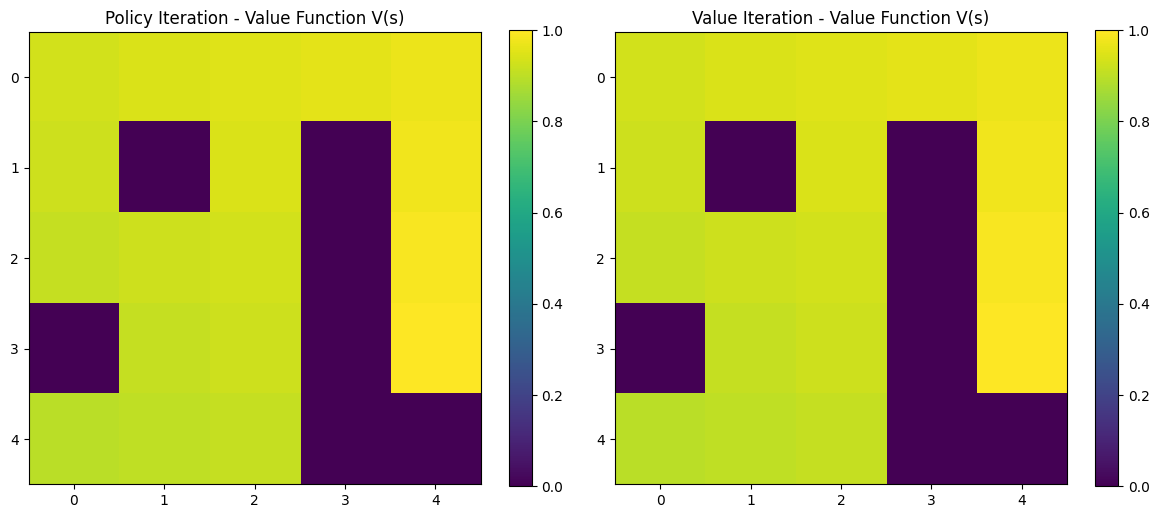

In [3]:
def show_video(video_folder):
    files = [f for f in os.listdir(video_folder) if f.endswith('.mp4')]
    if not files:
        print("لم يتم العثور على فيديو!")
        return
    video_path = os.path.join(video_folder, files[0])
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width=350 controls autoplay loop>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

print("--- 🎬 فيديو العميل باستخدام Policy Iteration ---")
display(show_video('./video_policy_iteration'))

print("\n--- 🎬 فيديو العميل باستخدام Value Iteration ---")
display(show_video('./video_value_iteration'))

# --------------------------------------------------
# رسم دالة القيمة V(s) للشبكة 5x5
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Policy Iteration Heatmap
im1 = axes[0].imshow(pi_V.reshape(5, 5), cmap='viridis')
axes[0].set_title('Policy Iteration - Value Function V(s)')
fig.colorbar(im1, ax=axes[0])

# Value Iteration Heatmap
im2 = axes[1].imshow(vi_V.reshape(5, 5), cmap='viridis')
axes[1].set_title('Value Iteration - Value Function V(s)')
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()